# Computer Vision and Image Processing (CSCS111/CSDS119)
## Lab Assignment 4: Statistical Order Filtering

**Objective:** Implement and analyze order statistics filtering techniques (Median, Min, Max, Midpoint, Alpha-trimmed mean, 25th and 75th Percentile filters) for image noise reduction and feature enhancement on the Cameraman image across multiple neighborhood sizes ($3 \times 3, 5 \times 5, 7 \times 7$).


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Cameraman image
img = cv2.imread('Filtering-Cameraman.png', cv2.IMREAD_GRAYSCALE)
print(f"Loaded Cameraman image with dimensions: {img.shape}")


Loaded Cameraman image with dimensions: (256, 256)


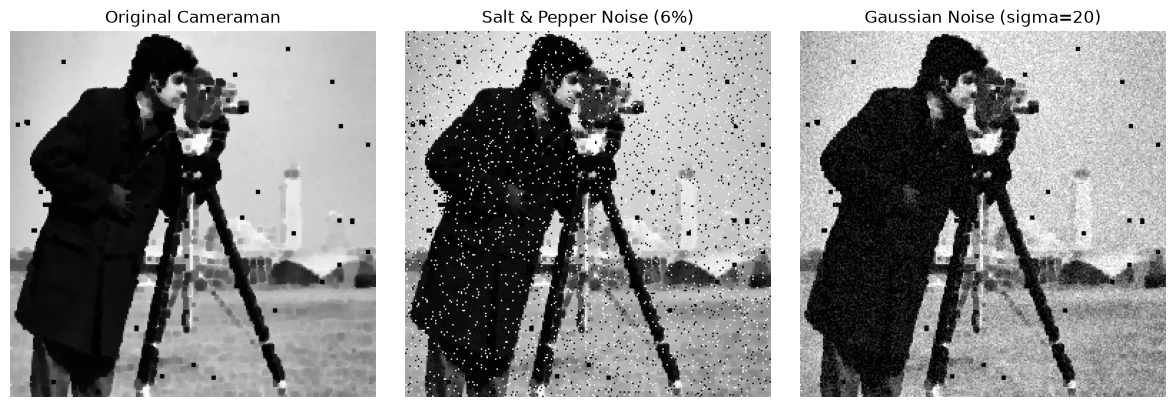

In [5]:
# Noise injection utilities
def add_salt_and_pepper_noise(image, salt_prob=0.03, pepper_prob=0.03):
    noisy = image.copy()
    rnd = np.random.rand(*image.shape)
    noisy[rnd < salt_prob] = 255
    noisy[(rnd >= salt_prob) & (rnd < salt_prob + pepper_prob)] = 0
    return noisy

def add_gaussian_noise(image, mean=0, sigma=20):
    noisy = image.astype(np.float32) + np.random.normal(mean, sigma, image.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)

np.random.seed(42)
noisy_sp = add_salt_and_pepper_noise(img)
noisy_gauss = add_gaussian_noise(img)

# Display original vs noisy inputs
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Cameraman")
axes[1].imshow(noisy_sp, cmap='gray')
axes[1].set_title("Salt & Pepper Noise (6%)")
axes[2].imshow(noisy_gauss, cmap='gray')
axes[2].set_title("Gaussian Noise (sigma=20)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


### 1. Statistical Order Filter Implementations
Order statistics filters extract a local $k \times k$ neighborhood around each pixel, sort the pixel values, and select or compute a central replacement value based on rank.


In [6]:
# Extract and sort sliding window neighborhoods (vectorized via NumPy)
def get_sorted_windows(image, k):
    pad = k // 2
    padded = np.pad(image, pad, mode='reflect')
    windows = np.lib.stride_tricks.sliding_window_view(padded, (k, k))
    return np.sort(windows.reshape(*image.shape, k * k), axis=-1)

# Statistical order filters
def median_filter(sw):
    return sw[..., sw.shape[-1] // 2]

def min_filter(sw):
    return sw[..., 0]

def max_filter(sw):
    return sw[..., -1]

def midpoint_filter(sw):
    return ((sw[..., 0].astype(float) + sw[..., -1].astype(float)) / 2).astype(np.uint8)

def alpha_trimmed_mean_filter(sw, alpha=0.2):
    d = max(1, int(alpha * sw.shape[-1]))  # trim d elements from each tail
    trimmed = sw[..., d : sw.shape[-1] - d]
    return np.clip(trimmed.mean(axis=-1), 0, 255).astype(np.uint8)

def percentile_filter(sw, p):
    idx = int(np.round((p / 100.0) * (sw.shape[-1] - 1)))
    return sw[..., idx]


### 2. Comparison of All Filters on Salt & Pepper Noise ($3 \times 3$)
We apply each filter to the salt-and-pepper noisy Cameraman image and display side-by-side results.


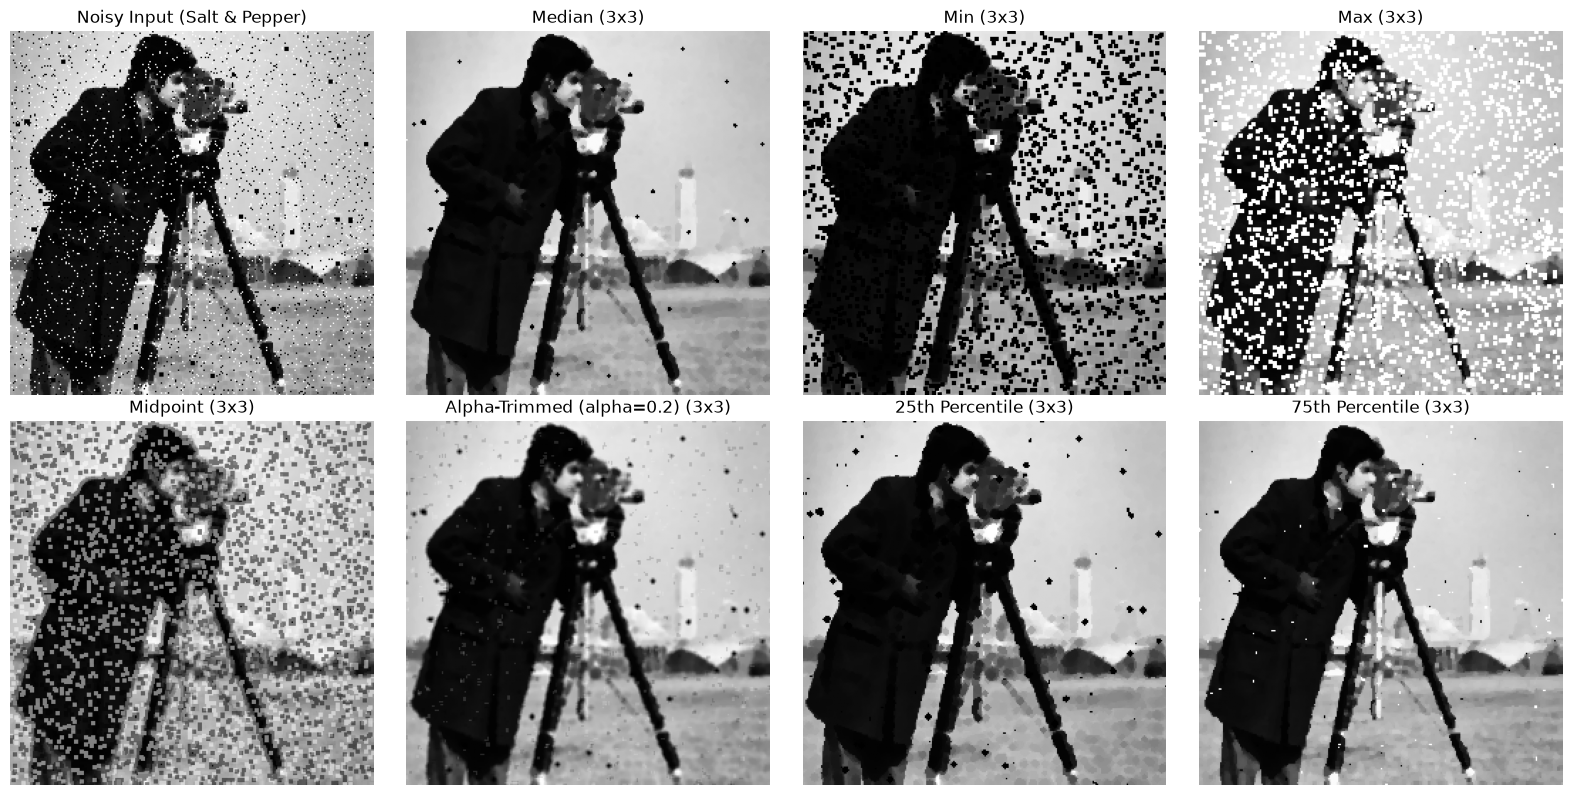

In [7]:
# Apply each filter on Salt & Pepper noisy image (3x3 neighborhood)
k = 3
sw_sp3 = get_sorted_windows(noisy_sp, k)

filters_3x3 = {
    "Median": median_filter(sw_sp3),
    "Min": min_filter(sw_sp3),
    "Max": max_filter(sw_sp3),
    "Midpoint": midpoint_filter(sw_sp3),
    "Alpha-Trimmed (alpha=0.2)": alpha_trimmed_mean_filter(sw_sp3, alpha=0.2),
    "25th Percentile": percentile_filter(sw_sp3, 25),
    "75th Percentile": percentile_filter(sw_sp3, 75)
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

axes[0].imshow(noisy_sp, cmap='gray')
axes[0].set_title("Noisy Input (Salt & Pepper)")
axes[0].axis('off')

for i, (name, filtered_img) in enumerate(filters_3x3.items(), start=1):
    axes[i].imshow(filtered_img, cmap='gray')
    axes[i].set_title(f"{name} (3x3)")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### 3. Impact of Neighborhood Sizes ($3 \times 3, 5 \times 5, 7 \times 7$)
We analyze the trade-off between noise reduction and preservation of fine image details across different kernel dimensions.


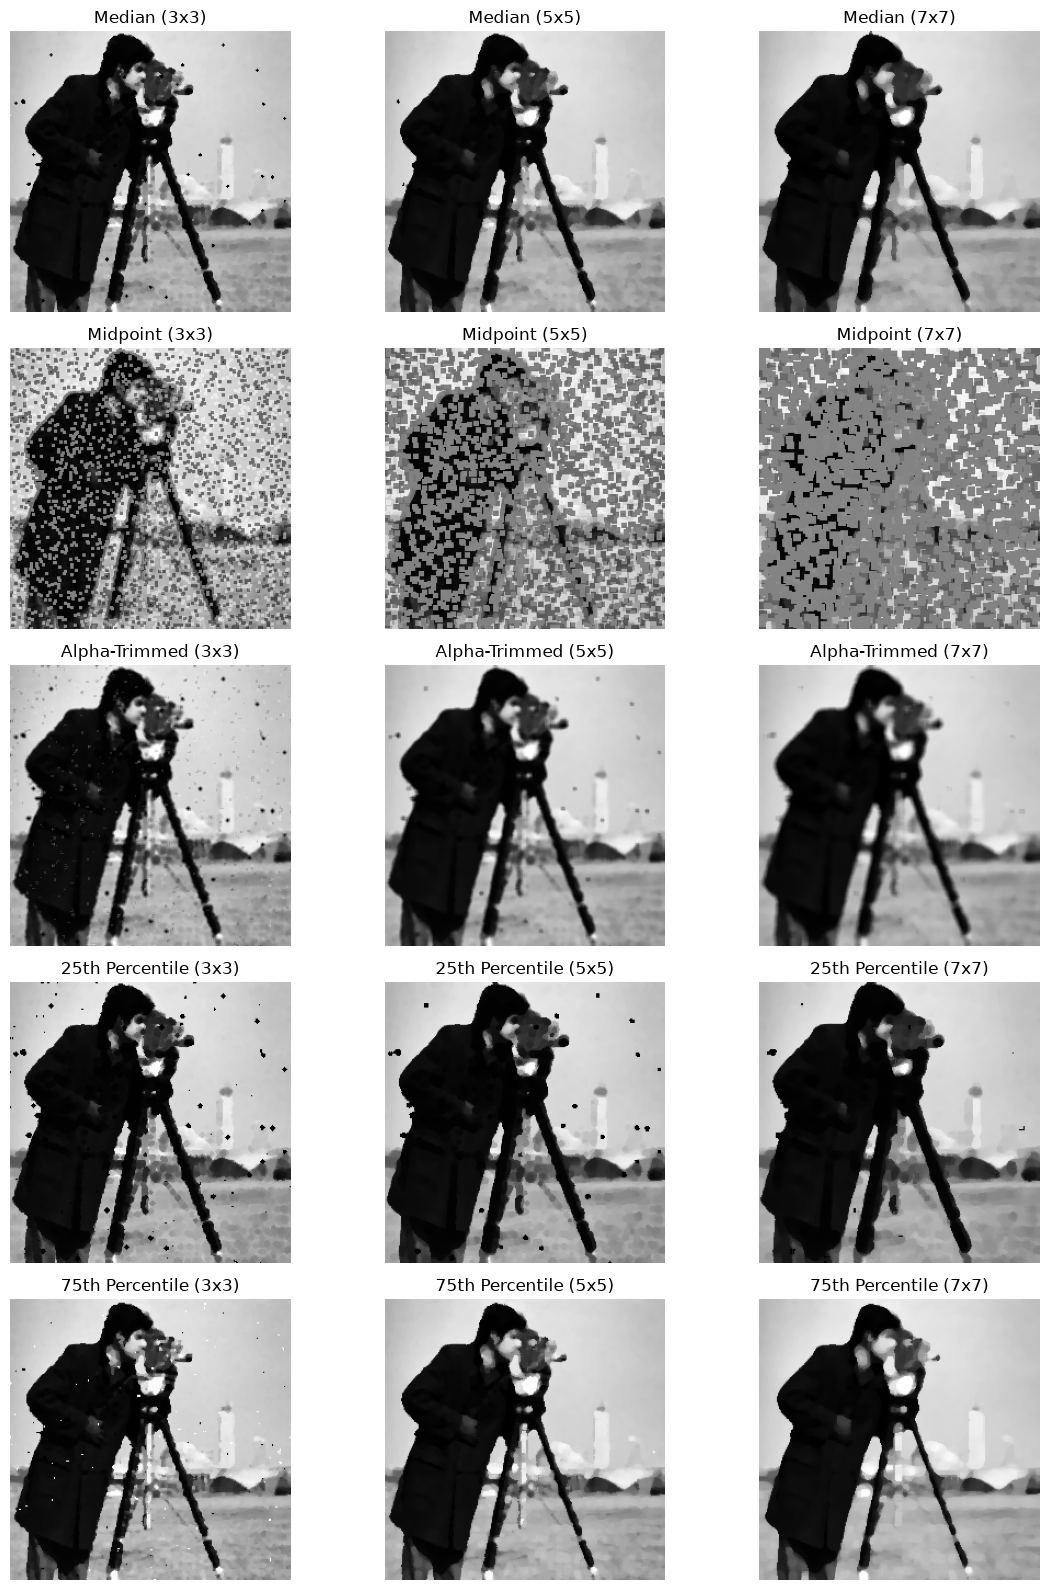

In [8]:
# Evaluate filters across neighborhood sizes 3x3, 5x5, and 7x7
sizes = [3, 5, 7]
filter_funcs = {
    "Median": median_filter,
    "Midpoint": midpoint_filter,
    "Alpha-Trimmed": lambda sw: alpha_trimmed_mean_filter(sw, alpha=0.2),
    "25th Percentile": lambda sw: percentile_filter(sw, 25),
    "75th Percentile": lambda sw: percentile_filter(sw, 75)
}

fig, axes = plt.subplots(len(filter_funcs), len(sizes), figsize=(12, 3.2 * len(filter_funcs)))

for r, (fname, ffunc) in enumerate(filter_funcs.items()):
    for c, sz in enumerate(sizes):
        sw = get_sorted_windows(noisy_sp, sz)
        res = ffunc(sw)
        axes[r, c].imshow(res, cmap='gray')
        axes[r, c].set_title(f"{fname} ({sz}x{sz})")
        axes[r, c].axis('off')

plt.tight_layout()
plt.show()


### 4. Evaluation on Additive Gaussian Noise
Testing Alpha-Trimmed Mean vs Median vs Midpoint on Gaussian noise to compare averaging and order-statistic properties.


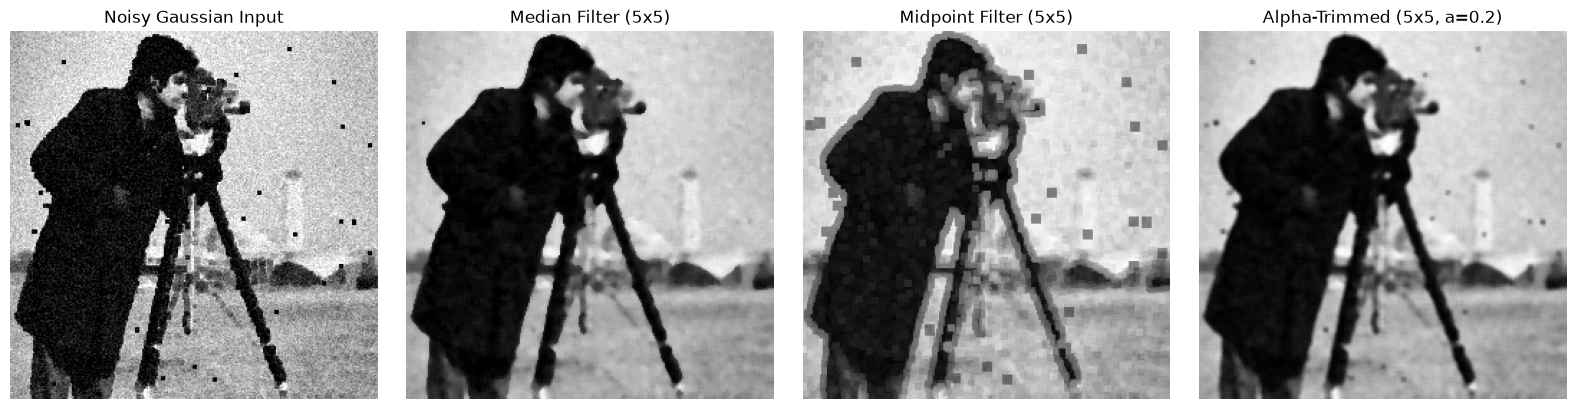

In [9]:
# Comparing filter performance on Gaussian noise (5x5 neighborhood)
k = 5
sw_g5 = get_sorted_windows(noisy_gauss, k)

gauss_results = {
    "Noisy Gaussian Input": noisy_gauss,
    "Median Filter (5x5)": median_filter(sw_g5),
    "Midpoint Filter (5x5)": midpoint_filter(sw_g5),
    "Alpha-Trimmed (5x5, a=0.2)": alpha_trimmed_mean_filter(sw_g5, alpha=0.2)
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, out_img) in zip(axes, gauss_results.items()):
    ax.imshow(out_img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


### 5. Observations and Comparative Analysis

1. **Comparison of Statistical Order Filtering Methods**:
   - **Median Filter**: Demonstrates superior performance for **salt-and-pepper noise**. Because impulse noise creates extreme outliers at the tails of the sorted distribution, the median completely ignores them while retaining sharp edge boundaries (tripod legs, coat silhouette).
   - **Min & Max Filters**:
     - *Min filter* replaces each pixel with the minimum neighborhood value, completely removing bright salt noise but causing dark regions/pepper noise to dilate and the entire image to darken.
     - *Max filter* replaces each pixel with the maximum value, completely removing dark pepper noise but causing bright structures to expand and salt noise to dilate.
   - **Midpoint Filter**: Evaluates $\frac{\min + \max}{2}$. It works well for short-tailed symmetric distributions like uniform noise, but is severely degraded by salt-and-pepper noise because outliers dominate the minimum and maximum.
   - **Alpha-Trimmed Mean Filter**: Offers an adjustable compromise between a pure median filter (when $\alpha \approx 0.5$) and an arithmetic mean filter (when $\alpha = 0$). By trimming extreme outliers from both tails and averaging the rest, it performs exceptionally well on Gaussian noise and mixed noise environments.
   - **Percentile / Ranked Filters (25th vs 75th)**:
     - Selecting ranks below the median (e.g., 25th percentile) biases pixel intensities toward lower values, eliminating bright salt impulses while slightly darkening the background.
     - Selecting ranks above the median (e.g., 75th percentile) biases intensities upward, eliminating dark pepper impulses while slightly brightening the image.

2. **Impact of Neighborhood Size ($3 \times 3, 5 \times 5, 7 \times 7$)**:
   - **$3 \times 3$ Size**: Best balance for moderate noise levels; efficiently suppresses isolated impulse noise pixels while preserving fine edge gradients and corner details.
   - **$5 \times 5$ Size**: Needed when noise density is higher or when noise impulses form small clusters. However, subtle textures and fine lines begin to soften.
   - **$7 \times 7$ Size**: Achieves heavy noise smoothing and suppresses dense noise clusters, but results in noticeable edge blurring, loss of fine features, and rounding of sharp corners.
